In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ISLP import load_data
Weekly = load_data("Weekly")

Weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


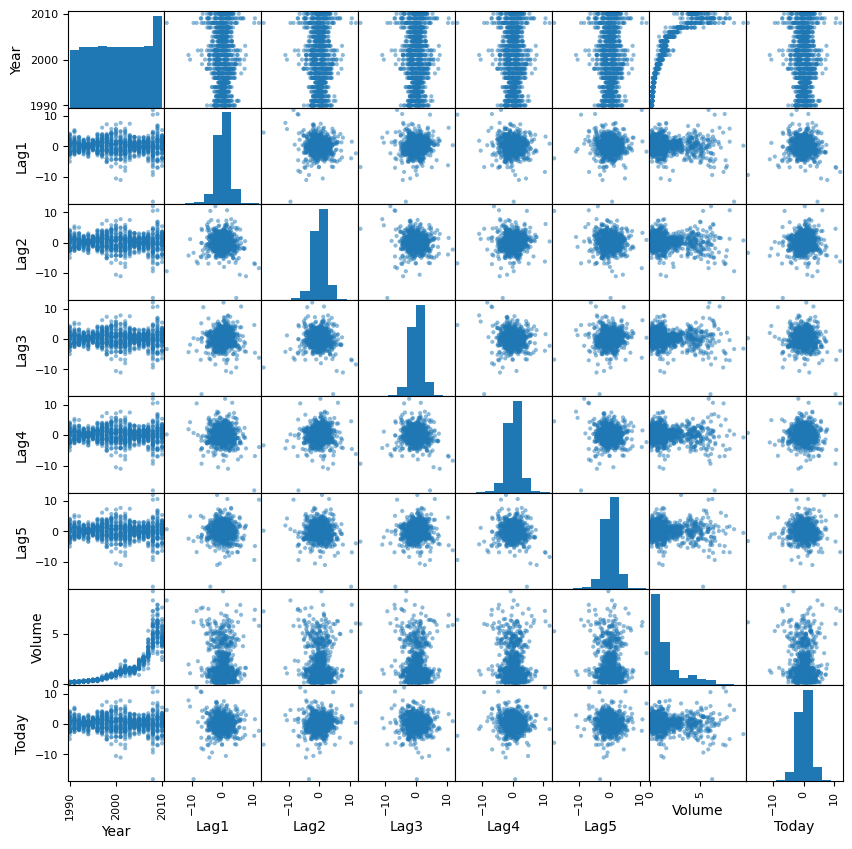

In [50]:
Weekly.describe()
from pandas.plotting import scatter_matrix
scatter_matrix(Weekly, figsize=(10,10))
plt.show()

In [51]:
import statsmodels.api as sm

X = Weekly[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]
y = Weekly['Direction']

y = (y == "Up").astype(int)

X = sm.add_constant(X)

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                0.006580
Time:                        21:33:19   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

In [52]:
import statsmodels.api as sm

X = Weekly[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]
y = Weekly['Direction']

y = (y == "Up").astype(int)

X = sm.add_constant(X)

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                0.006580
Time:                        21:33:19   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

In [53]:
from sklearn.metrics import confusion_matrix, accuracy_score

pred_probs = model.predict(X)
pred = (pred_probs > 0.5).astype(int)

confusion_matrix(y, pred), accuracy_score(y, pred)

(array([[ 54, 430],
        [ 48, 557]]),
 0.5610651974288338)

In [54]:
train = Weekly[Weekly['Year'] < 2009]
test = Weekly[Weekly['Year'] >= 2009]

X_train = sm.add_constant(train[['Lag2']])
y_train = (train['Direction'] == "Up").astype(int)

X_test = sm.add_constant(test[['Lag2']])
y_test = (test['Direction'] == "Up").astype(int)

model_lag2 = sm.Logit(y_train, X_train).fit()

pred_probs = model_lag2.predict(X_test)
pred = (pred_probs > 0.5).astype(int)

confusion_matrix(y_test, pred), accuracy_score(y_test, pred)

Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4


(array([[ 9, 34],
        [ 5, 56]]),
 0.625)

In [55]:
train = Weekly[Weekly['Year'] < 2009]
test = Weekly[Weekly['Year'] >= 2009]

X_train = sm.add_constant(train[['Lag2']])
y_train = (train['Direction'] == "Up").astype(int)

X_test = sm.add_constant(test[['Lag2']])
y_test = (test['Direction'] == "Up").astype(int)

model_lag2 = sm.Logit(y_train, X_train).fit()

pred_probs = model_lag2.predict(X_test)
pred = (pred_probs > 0.5).astype(int)

confusion_matrix(y_test, pred), accuracy_score(y_test, pred)

Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4


(array([[ 9, 34],
        [ 5, 56]]),
 0.625)

In [56]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()
qda.fit(train[['Lag2']], train['Direction'])

pred_qda = qda.predict(test[['Lag2']])

confusion_matrix(test['Direction'], pred_qda), accuracy_score(test['Direction'], pred_qda)

(array([[ 0, 43],
        [ 0, 61]]),
 0.5865384615384616)

In [57]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(train[['Lag2']], train['Direction'])

pred_knn = knn.predict(test[['Lag2']])

confusion_matrix(test['Direction'], pred_knn), accuracy_score(test['Direction'], pred_knn)

(array([[22, 21],
        [32, 29]]),
 0.49038461538461536)

In [58]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(train[['Lag2']], train['Direction'])

pred_nb = nb.predict(test[['Lag2']])

confusion_matrix(test['Direction'], pred_nb), accuracy_score(test['Direction'], pred_nb)

(array([[ 0, 43],
        [ 0, 61]]),
 0.5865384615384616)